        Disable GPU: Force tensorflow to select CPU

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="-1"    
import tensorflow as tf

2025-07-04 00:38:46.707433: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1751569726.727751 1417487 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1751569726.734039 1417487 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-04 00:38:46.755296: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


        Select a GPU with a memory limit

In [ ]:
#%% # include ../dirx 
import tensorflow as tf
print(f"TensorFlow version {tf.__version__}")
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
gpus = tf.config.list_physical_devices('GPU')
len(gpus)
mylibpath = [
    '/home/kishoretarafdar/bin',
    # '/data1/kishoretarafdar/src2D/GIIR/mra'
    #'/home/k/PLAYGROUND10GB/SKULSTRIPpaper__'
    ]
import sys
[sys.path.insert(1,_) for _ in mylibpath]
del mylibpath

from tf_select_a_gpu import select_a_gpu
# select_gpu = gpus[gpu_id]
memory_limit = 16#32 #GB
select_a_gpu(gpus, gpu_id = 2, memory_limit=memory_limit)
# del gpu_id, select_a_gpu, select_gpu

# from DWT1DFB import DWT1D, IDWT1D
# from DWT2DFB import DWT2D, IDWT2D


2025-02-16 01:13:42.313983: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-16 01:13:42.342984: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-16 01:13:42.343053: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1442] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-16 01:13:42.362690: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-16 01:13:43.401498: W tensorflow/compiler/tf

TensorFlow version 2.16.2
Num GPUs Available:  3


2025-02-16 01:13:45.349774: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1928] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 16384 MB memory:  -> device: 2, name: NVIDIA RTX A6000, pci bus id: 0000:41:00.0, compute capability: 8.6


3 Physical GPUs available 
Selected 1 Logical GPU with 16 GB memory limit


In [3]:

import matplotlib.pyplot as plt


        MIMO batch

In [4]:
import tensorflow as tf
from TFDWT.DWT1DFB import DWT1D, IDWT1D

#%% Shift invariant Linear (m=1) Multiresolution Volterra Kernel
class LSVariantVolterra1D(tf.keras.layers.Layer):
    """
        VolterraSysMRA: Multidimensional linear and nonlinear Volterra kernels in natural and biortogonal bases.
        Copyright (C) 2025 Kishore Kumar Tarafdar

        This program is free software: you can redistribute it and/or modify
        it under the terms of the GNU General Public License as published by
        the Free Software Foundation, either version 3 of the License, or
        (at your option) any later version.

        This program is distributed in the hope that it will be useful,
        but WITHOUT ANY WARRANTY; without even the implied warranty of
        MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the
        GNU General Public License for more details.

        You should have received a copy of the GNU General Public License
        along with this program.  If not, see <https://www.gnu.org/licenses/>.   
        
    
        Shift variant Linear (m=1) Multiresolution Volterra Kernel
        Input: sequence x[n]
        Output: Shift variant linear monomial y1, i.e., m=1

    --@KKT, 03Jul2025"""
    
    def __init__(self, filters=1, Ny=16, wave='haar', mra=True, **kwargs):
        super().__init__(**kwargs)
        # self.L = kernel_size
        self.wave = wave
        self.filters = filters
        self.Ny = Ny
        self.mra = mra
    
    def build(self, input_shape):
        # input_shape: (batch_size, N, N, channels)
        self.N = input_shape[1]
        # self.L = self.N
        self.channels = input_shape[-1]
        kernel_shape = (self.Ny, self.N, input_shape[-1], self.filters)
        # kernel_shape = (self.L, input_shape[-1])
        self.h1 = self.add_weight(
            shape=kernel_shape,
            initializer='glorot_uniform',
            trainable=True,
            # regularizer=self.kernel_regularizer,
            name='kernel'
        )
        # n = tf.range(self.N)
        # self.row_indices = tf.math.mod(n[:, tf.newaxis] - n, self.N)
        super().build(input_shape)

    def call(self, x):  
        self.x = x  
        if self.mra==True:
            return self.__compute_output_with_mra_kernel(x)
        else: 
            return self.__compute_output_in_natural_domain(x)

    def __compute_output_with_mra_kernel(self, x):
        HT = self.__make_H()
        print(HT.shape,'HT')
        ## l-axis below --->l and ^v
        
        ## H[v,l] 
        α = DWT1D(self.wave, clean=False)(x)
        # print('α = ', α.shape)
        print('HT and α', HT.shape, α.shape)
        β = tf.einsum('bic,uico->buo',α, HT) #HT and α (16, 4, 1, 1) (None, 4, 1)
        # β = tf.einsum('buco->buo',β)
        print('β', β.shape)

        # HTα = HT * α
        # print(HTα.shape, '\n', tf.squeeze(HTα).numpy())
        # beta = tf.expand_dims(tf.einsum('ijk->ik',HTα), axis=-1)
        
        # βT = tf.transpose(beta, perm=[1,0,2])
        # print('βT',tf.squeeze(βT).numpy())
        y = IDWT1D(self.wave, clean=False)(β)#
        # print('y',tf.squeeze(y).numpy())
        return y
         
    def __compute_output_in_natural_domain(self, x):
        ynatural = tf.einsum('bic,uico->buo',x, self.h1)
        # print(ynatural.shape, 'natural y') 
        return ynatural

    def sanity_check(self):
        return self.__compute_output_with_mra_kernel(self.x),  self.__compute_output_in_natural_domain(self.x)  
    
    def __make_H(self):
        def mra_kernel(h):
            shape = tf.shape(h)
            Ny, N, channels, filters = shape[0], shape[1], shape[2], shape[3]
            
            # Combine channels and filters: shape becomes (Ny, N, in_channels * filters)
            h1_reshaped = tf.reshape(self.h1, [Ny, N, -1])
            print(h1_reshaped.shape, 'h1_reshaped')

            # Apply DWT1D twice
            dwt_layer1 = DWT1D(self.wave, clean=False)
            dwt_layer2 = DWT1D(self.wave, clean=False)
            
            dwt_once = dwt_layer1(h1_reshaped)
            # print(dwt_once.shape, 'dwt once')
            dwt_once_T = tf.transpose(dwt_once, perm=[1, 0, 2])
            # print(dwt_once_T.shape, 'dwt once T')  
            dwt_twice = dwt_layer2(dwt_once_T)
            # print(dwt_twice.shape, 'dwt twice')

            # Final transpose to (Ny, N, in_channels * filters)
            tmp_H = tf.transpose(dwt_twice, perm=[1, 0, 2])

            # Reshape back to (Ny, N, in_channels, filters)
            H = tf.reshape(tmp_H, [self.h1.shape[0], self.h1.shape[1], self.h1.shape[2], self.h1.shape[3]])
            print(H.shape,'in mra kernel HT')
            return H
        
        if self.mra == True:
            return mra_kernel(self.h1)
        else:
            return self.h1
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'Ny': self.Ny,
            'wavelet': self.wave,
            'filters': self.filters
        })
        return config



if __name__=='__main__':
    import os
    os.environ["CUDA_VISIBLE_DEVICES"]="-1"   
    ## Example
    # Functional model
    N, channels = 4, 1
    input_shape = (N, channels) 
    inputs = tf.keras.Input(shape=input_shape)
    filters, Ny = 1, 16
    H = LSVariantVolterra1D(filters=filters, Ny=Ny, wave='haar')
    # H = LSVariantVolterra1D(filters=filters, Ny=Ny, wave='haar', mra=False)
    outputs = H(inputs)
    # Build the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer='adam', loss='mse', jit_compile=False)
    model.summary()
    ## 1D
    inputs_data = tf.random.normal((1, N, 1))
    targets = tf.random.normal((1, Ny, 1))
    # Training loop for 5 epochs
    epochs=5
    history = model.fit(inputs_data, targets, epochs=5, verbose=1)





        # self.h1 = h

        # paddings = [
        #    [0,0],#self.N - self.L],  # Depth dimension
        #    [0,0], #self.N - self.L],  # Depth dimension
        #    [0,0],
        #    [0,0]
        # ]
        # h_padded = tf.pad(self.h1, paddings, mode='CONSTANT', constant_values=0)
        # print(h_padded.shape,'>h_padded')
        # hshifted = h_padded
        # self.h_padded = h_padded


        ## PERFECT (slower)
        # HT = tf.stack(
        #     [
        #         tf.concat(
        #             [
        #                 tf.transpose(
        #                     DWT1D(self.wave, clean=False)(
        #                         tf.transpose(DWT1D(self.wave, clean=False)(self.h1[...,i:i+1,j]), perm=[1,0,2])),
        #                             perm=[1,0,2]) 
        #                             for i in range(self.channels)
        #                             ], axis=-1) for j in range(self.filters)], axis=-1)
        # print(HT.shape, 'HT')

        ## PERFECT (less slower)
        # HT = tf.stack(
        #     [
        #         tf.concat([
        #             tf.transpose(
        #                 DWT1D(self.wave, clean=False)(
        #                     tf.transpose(DWT1D(self.wave, clean=False)(self.h1[...,j]), perm=[1,0,2])),
        #                     perm=[1,0,2])] , axis=-1) for j in range(self.filters)], axis=-1)
        # return HT



2025-07-04 00:39:17.778885: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2025-07-04 00:39:17.778950: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:137] retrieving CUDA diagnostic information for host: meherangarh
2025-07-04 00:39:17.778958: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:144] hostname: meherangarh
2025-07-04 00:39:17.779168: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:168] libcuda reported version is: 570.148.8
2025-07-04 00:39:17.779209: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:172] kernel reported version is: 570.148.8
2025-07-04 00:39:17.779215: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:259] kernel version seems to match DSO: 570.148.8


(16, 4, 1) h1_reshaped
(16, 4, 1, 1) in mra kernel HT
(16, 4, 1, 1) HT
HT and α (16, 4, 1, 1) (None, 4, 1)
β (None, 16, 1)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ls_variant_volterra1d           │ (None, 16, 1)          │            64 │
│ (LSVariantVolterra1D)           │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 64 (256.00 B)

 Trainable params: 64 (256.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
(16, 4, 1) h1_reshaped
(16, 4, 1, 1) in mra kernel HT
(16, 4, 1, 1) HT
HT and α (16, 4, 1, 1) (None, 4, 1)
β (None, 16, 1)
(16, 4, 1) h1_reshaped
(16, 4, 1, 1) in mra kernel HT
(16, 4, 1, 1) HT
HT and α (16, 4, 1, 1) (None, 4, 1)
β (None, 16, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 852ms/step - loss: 0.4765
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.4717
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.4670
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.4624
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.4577


In [5]:
x = tf.constant([1,2,3,5,5,3,2,1], dtype=tf.float32)
x = tf.constant([1,1,1,1,1,1,1,1,1,0,0,0,0,0,0,1], dtype=tf.float32)
# x = tf.constant([1,0,0,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0,0,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([1,0,0,0], dtype=tf.float32)
# x = tf.constant([0,1,0,0], dtype=tf.float32)
# x = tf.constant([0,0,1,0], dtype=tf.float32)
# x = tf.constant([3.,0,7.,0], dtype=tf.float32)
# x = tf.constant([1.,7.,11.,13.], dtype=tf.float32)
# x = tf.constant([3.,7.], dtype=tf.float32)
# x = tf.constant([1,1,1,1], dtype=tf.float32)
# x = tf.constant([21,3,4,5], dtype=tf.float32)
# x = tf.constant([.1,.1,.1,.1], dtype=tf.float32)
x.shape
# lay = LSVariantVolterra1Dmra(filters=1, Ny=21)
# y = lay(xx)
# y = lay(tf.concat([xx,xx], axis=-1))
# y.shape

TensorShape([16])

In [6]:
_ = tf.expand_dims(tf.expand_dims(x,axis=-1),axis=0)
_.shape

TensorShape([1, 16, 1])

        batch test

In [7]:
lay = LSVariantVolterra1D(filters=1, Ny=Ny, wave='haar')
y = lay(_)

(16, 16, 1) h1_reshaped
(16, 16, 1, 1) in mra kernel HT
(16, 16, 1, 1) HT
HT and α (16, 16, 1, 1) (1, 16, 1)
β (1, 16, 1)


In [8]:
# lay = LSVariantVolterra1Dmra(filters=1, Ny=Ny, wave='haar')
y, ynat = lay.sanity_check()
y.shape, ynat.shape

(16, 16, 1) h1_reshaped
(16, 16, 1, 1) in mra kernel HT
(16, 16, 1, 1) HT
HT and α (16, 16, 1, 1) (1, 16, 1)
β (1, 16, 1)


(TensorShape([1, 16, 1]), TensorShape([1, 16, 1]))

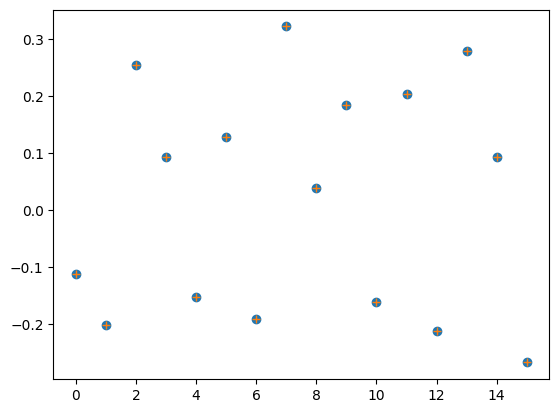

In [9]:
y, ynat
plt.plot(tf.squeeze(y).numpy(), 'o')
plt.plot(tf.squeeze(ynat).numpy(), '+')

In [ ]:
break

---


        Rough

In [73]:
h1 = lay.h1.numpy()
h1.shape, tf.squeeze(h1).numpy()

((21, 16, 1, 1),
 array([[-0.03537886,  0.08115158,  0.01557066,  0.07997478, -0.02300906,
         -0.01307442, -0.06729291, -0.00821572,  0.05348141,  0.01999683,
         -0.02571238,  0.00296994,  0.02986491, -0.05761229, -0.08592855,
         -0.02013477],
        [ 0.00945956,  0.08876387, -0.07012037, -0.00871015,  0.0096319 ,
          0.04565953,  0.09274512,  0.08005735,  0.08750515, -0.01679324,
         -0.02437823, -0.06122306, -0.05487153, -0.02703554, -0.07955064,
          0.02073871],
        [ 0.00217972,  0.04835155, -0.08988103, -0.06133964, -0.01668531,
         -0.01544639,  0.01391976,  0.01493268, -0.08043321, -0.06465092,
         -0.06013316, -0.0727022 ,  0.03753211, -0.06032278,  0.00515115,
          0.0541549 ],
        [-0.09344997, -0.07183501,  0.01068319, -0.04899818,  0.06114233,
         -0.06788836, -0.02168348,  0.03600644,  0.074301  , -0.06082108,
          0.08689707, -0.05054613,  0.04384937, -0.07430875, -0.06974471,
          0.03229211],
   

In [6]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

3 Verify
---

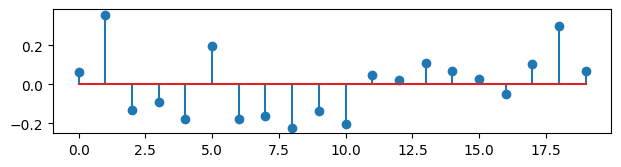

In [74]:
# plt.subplot(3,1,1), plt.stem(tf.squeeze(yhat).numpy())
plt.subplot(3,1,2), plt.stem(tf.squeeze(y).numpy())
# plt.subplot(3,1,3), plt.stem(tf.squeeze(y1n).numpy()), plt.title('natural')
plt.tight_layout()

In [75]:
tf.reduce_sum(tf.square(tf.squeeze(yhat))).numpy(), tf.reduce_sum(tf.square(tf.squeeze(y1n))).numpy(), tf.reduce_sum(tf.square(tf.squeeze(y))).numpy()


(np.float32(6.814312), np.float32(2.6535373), np.float32(0.5152701))

In [ ]:
break

2 BUILD
---


In [76]:
# x = [0,0,0,0,1,1,1,1]
wave = 'haar'
# wave = 'db2'
# wave = 'db3'

## filter init
# h = tf.constant([1,2,3,5], dtype=tf.float32)
h = tf.squeeze(lay.h1.numpy())
# h = tf.constant([1,2,3,4], dtype=tf.float32)
# h = tf.constant([1,1,1,1], dtype=tf.float32)
# h = tf.constant([1,1], dtype=tf.float32)

# h = tf.constant([1.,5.], dtype=tf.float32)
# h = tf.constant([1,0,0,0], dtype=tf.float32)
## Matching filter size with input size with zero padding
x.shape, h.shape

(TensorShape([16]), TensorShape([21, 16]))

In [77]:
lay.h1

<KerasVariable shape=(21, 16, 1, 1), dtype=float32, path=ls_variant_volterra1_dmra/kernel>

In [78]:
L = Npoint#h.shape[0]

# row_indices = tf.math.mod(n[:, tf.newaxis] - n, L)
Npoint = len(x)
# paddings = [
#            [0, Npoint - L],  # Depth dimension
#            [0, Npoint - L]  # Depth dimension
#         ]
# h_padded = tf.pad(h, paddings, mode='CONSTANT', constant_values=0)
# h_padded.shape


## Creating x[n-k] for all n
N = Npoint
n = tf.range(N)
row_indices = tf.math.mod(n[:, tf.newaxis]-n, N)
print(row_indices)
hshifted = tf.gather(h, row_indices, axis=0)
print(x.shape, h.shape, hshifted.shape), 
x, h, hshifted

tf.Tensor(
[[ 0 15 14 13 12 11 10  9  8  7  6  5  4  3  2  1]
 [ 1  0 15 14 13 12 11 10  9  8  7  6  5  4  3  2]
 [ 2  1  0 15 14 13 12 11 10  9  8  7  6  5  4  3]
 [ 3  2  1  0 15 14 13 12 11 10  9  8  7  6  5  4]
 [ 4  3  2  1  0 15 14 13 12 11 10  9  8  7  6  5]
 [ 5  4  3  2  1  0 15 14 13 12 11 10  9  8  7  6]
 [ 6  5  4  3  2  1  0 15 14 13 12 11 10  9  8  7]
 [ 7  6  5  4  3  2  1  0 15 14 13 12 11 10  9  8]
 [ 8  7  6  5  4  3  2  1  0 15 14 13 12 11 10  9]
 [ 9  8  7  6  5  4  3  2  1  0 15 14 13 12 11 10]
 [10  9  8  7  6  5  4  3  2  1  0 15 14 13 12 11]
 [11 10  9  8  7  6  5  4  3  2  1  0 15 14 13 12]
 [12 11 10  9  8  7  6  5  4  3  2  1  0 15 14 13]
 [13 12 11 10  9  8  7  6  5  4  3  2  1  0 15 14]
 [14 13 12 11 10  9  8  7  6  5  4  3  2  1  0 15]
 [15 14 13 12 11 10  9  8  7  6  5  4  3  2  1  0]], shape=(16, 16), dtype=int32)
(16,) (21, 16) (16, 16, 16)


(<tf.Tensor: shape=(16,), dtype=float32, numpy=
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 0., 0., 0., 0., 0., 0., 1.],
       dtype=float32)>,
 <tf.Tensor: shape=(21, 16), dtype=float32, numpy=
 array([[-0.03537886,  0.08115158,  0.01557066,  0.07997478, -0.02300906,
         -0.01307442, -0.06729291, -0.00821572,  0.05348141,  0.01999683,
         -0.02571238,  0.00296994,  0.02986491, -0.05761229, -0.08592855,
         -0.02013477],
        [ 0.00945956,  0.08876387, -0.07012037, -0.00871015,  0.0096319 ,
          0.04565953,  0.09274512,  0.08005735,  0.08750515, -0.01679324,
         -0.02437823, -0.06122306, -0.05487153, -0.02703554, -0.07955064,
          0.02073871],
        [ 0.00217972,  0.04835155, -0.08988103, -0.06133964, -0.01668531,
         -0.01544639,  0.01391976,  0.01493268, -0.08043321, -0.06465092,
         -0.06013316, -0.0727022 ,  0.03753211, -0.06032278,  0.00515115,
          0.0541549 ],
        [-0.09344997, -0.07183501,  0.01068319, -0.04899818,  0.06114

In [79]:
hshifted[1,:] * x

<tf.Tensor: shape=(16, 16), dtype=float32, numpy=
array([[ 0.00945956,  0.08876387, -0.07012037, -0.00871015,  0.0096319 ,
         0.04565953,  0.09274512,  0.08005735,  0.08750515, -0.        ,
        -0.        , -0.        , -0.        , -0.        , -0.        ,
         0.02073871],
       [-0.03537886,  0.08115158,  0.01557066,  0.07997478, -0.02300906,
        -0.01307442, -0.06729291, -0.00821572,  0.05348141,  0.        ,
        -0.        ,  0.        ,  0.        , -0.        , -0.        ,
        -0.02013477],
       [-0.08045506,  0.07933054,  0.07366335, -0.00189771, -0.03598337,
         0.07737561, -0.05558309, -0.07338537,  0.0022277 , -0.        ,
         0.        ,  0.        , -0.        ,  0.        ,  0.        ,
         0.03992326],
       [-0.0124849 ,  0.06004802,  0.08353988,  0.03294956,  0.0360624 ,
        -0.06969792, -0.05998411, -0.08002031,  0.00810659,  0.        ,
        -0.        , -0.        , -0.        , -0.        , -0.        ,
        

In [ ]:
# tf.reverse(tf.reverse(tf.math.mod(n[:, tf.newaxis] - n, N), axis=[0]), axis=[-1])

        True value

In [80]:
res = []
for r in range(x.shape[0]):
    res.append(tf.reduce_sum(x * hshifted[r,:]))
y1n = tf.stack(res,axis=-1)
y1n
## OK

<tf.Tensor: shape=(16,), dtype=float32, numpy=
array([-0.40724206, -0.40724206, -0.40724203, -0.40724203, -0.407242  ,
       -0.40724197, -0.40724203, -0.40724203, -0.40724206, -0.40724206,
       -0.40724212, -0.4072421 , -0.4072421 , -0.40724206, -0.40724206,
       -0.40724206], dtype=float32)>

In [81]:
DWT1D(wave, clean=False)(tf.expand_dims(tf.expand_dims(y1n, axis=0), axis=-1))

<tf.Tensor: shape=(1, 16, 1), dtype=float32, numpy=
array([[[-5.7592726e-01],
        [-5.7592720e-01],
        [-5.7592714e-01],
        [-5.7592720e-01],
        [-5.7592726e-01],
        [-5.7592726e-01],
        [-5.7592726e-01],
        [-5.7592726e-01],
        [ 0.0000000e+00],
        [ 0.0000000e+00],
        [-2.9802322e-08],
        [ 0.0000000e+00],
        [ 0.0000000e+00],
        [-2.9802322e-08],
        [ 0.0000000e+00],
        [ 0.0000000e+00]]], dtype=float32)>

---

In [82]:
h.numpy(), hshifted.numpy(), hshifted[0,:].numpy(), hshifted[1,:].numpy(), x.numpy(), tf.reduce_sum(hshifted[1,:]*x).numpy() 
## OK  ## n-axis --->n

(array([[-0.03537886,  0.08115158,  0.01557066,  0.07997478, -0.02300906,
         -0.01307442, -0.06729291, -0.00821572,  0.05348141,  0.01999683,
         -0.02571238,  0.00296994,  0.02986491, -0.05761229, -0.08592855,
         -0.02013477],
        [ 0.00945956,  0.08876387, -0.07012037, -0.00871015,  0.0096319 ,
          0.04565953,  0.09274512,  0.08005735,  0.08750515, -0.01679324,
         -0.02437823, -0.06122306, -0.05487153, -0.02703554, -0.07955064,
          0.02073871],
        [ 0.00217972,  0.04835155, -0.08988103, -0.06133964, -0.01668531,
         -0.01544639,  0.01391976,  0.01493268, -0.08043321, -0.06465092,
         -0.06013316, -0.0727022 ,  0.03753211, -0.06032278,  0.00515115,
          0.0541549 ],
        [-0.09344997, -0.07183501,  0.01068319, -0.04899818,  0.06114233,
         -0.06788836, -0.02168348,  0.03600644,  0.074301  , -0.06082108,
          0.08689707, -0.05054613,  0.04384937, -0.07430875, -0.06974471,
          0.03229211],
        [-0.04158056

In [ ]:
# hshifted = tf.reverse(hshifted, axis=[1,0])
# hshifted

In [83]:
tf.expand_dims(hshifted[0:1,:], axis=-1)

<tf.Tensor: shape=(1, 16, 16, 1), dtype=float32, numpy=
array([[[[-0.03537886],
         [ 0.08115158],
         [ 0.01557066],
         [ 0.07997478],
         [-0.02300906],
         [-0.01307442],
         [-0.06729291],
         [-0.00821572],
         [ 0.05348141],
         [ 0.01999683],
         [-0.02571238],
         [ 0.00296994],
         [ 0.02986491],
         [-0.05761229],
         [-0.08592855],
         [-0.02013477]],

        [[-0.08045506],
         [ 0.07933054],
         [ 0.07366335],
         [-0.00189771],
         [-0.03598337],
         [ 0.07737561],
         [-0.05558309],
         [-0.07338537],
         [ 0.0022277 ],
         [-0.03255729],
         [ 0.05515856],
         [ 0.01171134],
         [-0.0667785 ],
         [ 0.07184406],
         [ 0.00054803],
         [ 0.03992326]],

        [[-0.0124849 ],
         [ 0.06004802],
         [ 0.08353988],
         [ 0.03294956],
         [ 0.0360624 ],
         [-0.06969792],
         [-0.05998411],
    

In [84]:
_.shape

TensorShape([1, 16, 1])

In [85]:
# _ = tf.expand_dims(hshifted, axis=-1)
_ = hshifted
hinit = DWT1D(wave, clean=False)(_)
# del _
print(tf.squeeze(hinit)) # l-axis below --->l  and n-axis ^

# OK
_ = _[1:2,...]
print(tf.squeeze(_).numpy())
tf.squeeze(DWT1D(wave, clean=False)(_)).numpy() # 

tf.Tensor(
[[[-0.08190695  0.113478    0.06309798 ...  0.01006338 -0.06037315
    0.01399257]
  [-0.00582229 -0.00662002  0.10918867 ... -0.01248601 -0.01130039
    0.02835686]
  [-0.05878896 -0.01477129 -0.04763999 ...  0.01338188 -0.00307463
   -0.03843574]
  ...
  [-0.07759601 -0.0531515  -0.06416169 ... -0.08070188  0.10271459
    0.02947044]
  [ 0.03667721  0.02225805 -0.04282517 ...  0.07647197  0.1108712
   -0.08741708]
  [-0.00514762 -0.02857582 -0.0139729  ... -0.02353763  0.05989321
    0.02362881]]

 [[-0.01832772  0.12014836 -0.03857247 ... -0.05985506 -0.11701146
    0.00042705]
  [-0.06571848  0.09855553  0.11115947 ... -0.00196381 -0.03342212
    0.07636953]
  [-0.01997823 -0.07138976 -0.01446753 ... -0.00311848  0.03914461
   -0.01882922]
  ...
  [-0.00258261  0.04085023  0.02179375 ...  0.07912223 -0.04964462
   -0.04359841]
  [ 0.0873035   0.04703162  0.05457286 ...  0.0158349  -0.12374724
    0.05047142]
  [-0.0676204  -0.08498473  0.07110964 ... -0.00988957 -0.05295

array([[-1.83277167e-02,  1.20148361e-01, -3.85724679e-02,
         5.03917038e-02, -9.45908017e-03,  2.30411552e-02,
         1.79974288e-02,  5.07997014e-02,  9.96925533e-02,
         2.26528291e-03, -3.54194045e-02, -4.11911719e-02,
        -1.76823437e-02, -5.98550551e-02, -1.17011458e-01,
         4.27053397e-04],
       [-6.57184795e-02,  9.85555276e-02,  1.11159466e-01,
         2.19569746e-02,  5.58821557e-05,  5.42895216e-03,
        -8.17183405e-02, -1.08474195e-01,  7.30744656e-03,
         7.14379502e-03, -5.24531864e-03,  7.95436371e-03,
        -9.99684334e-02, -1.96380727e-03, -3.34221199e-02,
         7.63695315e-02],
       [-1.99782252e-02, -7.13897571e-02, -1.44675281e-02,
        -5.29707894e-02,  3.24352719e-02,  1.09204538e-02,
         4.92978245e-02,  7.43997023e-02,  1.02010764e-01,
         2.00318955e-02,  1.21120503e-02, -4.32931632e-02,
         2.62516364e-02, -3.11847706e-03,  3.91446054e-02,
        -1.88292246e-02],
       [-4.05959152e-02, -4.33416888e

In [86]:
hinitT = tf.transpose(hinit, perm=[1,0,2])
print(hinit.shape, '\n', tf.squeeze(hinitT).numpy()) # n-axis below --->n  and ^l

(16, 16, 16) 
 [[[-0.08190695  0.113478    0.06309798 ...  0.01006338 -0.06037315
    0.01399257]
  [-0.01832772  0.12014836 -0.03857247 ... -0.05985506 -0.11701146
    0.00042705]
  [ 0.00823021  0.09695524 -0.11313808 ... -0.06177166 -0.05260838
    0.05295778]
  ...
  [-0.01997823 -0.07138976 -0.01446753 ... -0.00311848  0.03914461
   -0.01882922]
  [-0.00582229 -0.00662002  0.10918867 ... -0.01248601 -0.01130039
    0.02835686]
  [-0.06571848  0.09855553  0.11115947 ... -0.00196381 -0.03342212
    0.07636953]]

 [[-0.00582229 -0.00662002  0.10918867 ... -0.01248601 -0.01130039
    0.02835686]
  [-0.06571848  0.09855553  0.11115947 ... -0.00196381 -0.03342212
    0.07636953]
  [-0.08190695  0.113478    0.06309798 ...  0.01006338 -0.06037315
    0.01399257]
  ...
  [-0.04059592 -0.04334169 -0.02924799 ...  0.05266372 -0.06168823
   -0.10269568]
  [-0.05878896 -0.01477129 -0.04763999 ...  0.01338188 -0.00307463
   -0.03843574]
  [-0.01997823 -0.07138976 -0.01446753 ... -0.00311848  0.

In [87]:
H = DWT1D(wave, clean=False)(hinitT)

print(tf.squeeze(hinitT).numpy(), '\n\n', tf.squeeze(H).numpy())

##OK
print('\n\n',tf.squeeze(hinitT[0:1,...]).numpy(),'\n',tf.squeeze(DWT1D(wave, clean=False)(hinitT[0:1,...])).numpy())
print('\n',tf.squeeze(hinitT[1:2,...]).numpy(),'\n',tf.squeeze(DWT1D(wave, clean=False)(hinitT[1:2,...])).numpy())
## v-axis below --->v and ^l

[[[-0.08190695  0.113478    0.06309798 ...  0.01006338 -0.06037315
    0.01399257]
  [-0.01832772  0.12014836 -0.03857247 ... -0.05985506 -0.11701146
    0.00042705]
  [ 0.00823021  0.09695524 -0.11313808 ... -0.06177166 -0.05260838
    0.05295778]
  ...
  [-0.01997823 -0.07138976 -0.01446753 ... -0.00311848  0.03914461
   -0.01882922]
  [-0.00582229 -0.00662002  0.10918867 ... -0.01248601 -0.01130039
    0.02835686]
  [-0.06571848  0.09855553  0.11115947 ... -0.00196381 -0.03342212
    0.07636953]]

 [[-0.00582229 -0.00662002  0.10918867 ... -0.01248601 -0.01130039
    0.02835686]
  [-0.06571848  0.09855553  0.11115947 ... -0.00196381 -0.03342212
    0.07636953]
  [-0.08190695  0.113478    0.06309798 ...  0.01006338 -0.06037315
    0.01399257]
  ...
  [-0.04059592 -0.04334169 -0.02924799 ...  0.05266372 -0.06168823
   -0.10269568]
  [-0.05878896 -0.01477129 -0.04763999 ...  0.01338188 -0.00307463
   -0.03843574]
  [-0.01997823 -0.07138976 -0.01446753 ... -0.00311848  0.03914461
   -0.

In [88]:
HT = tf.transpose(H, perm=[1,0,2])
print(HT.shape, '\n', tf.squeeze(HT).numpy())   ## l-axis below --->l and ^v
# HT=H

(16, 16, 16) 
 [[[-7.08766133e-02  1.65198788e-01  1.73421521e-02 ... -3.52080278e-02
   -1.25429854e-01  1.01962155e-02]
  [-5.05869649e-02  6.50082231e-02  1.55809656e-01 ... -1.02175642e-02
   -3.16235870e-02  7.40527362e-02]
  [-5.56968078e-02 -6.09250627e-02 -4.39166464e-02 ...  7.25731906e-03
    2.55053211e-02 -4.04924452e-02]
  ...
  [-5.66948429e-02 -8.69830698e-03 -2.99586523e-02 ... -1.11698150e-03
    3.75261344e-02 -9.98998620e-03]
  [ 8.76675993e-02  4.89951931e-02  8.30686651e-03 ...  6.52708113e-02
   -9.10473615e-03 -2.61245258e-02]
  [-5.14547564e-02 -8.02994370e-02  4.04017754e-02 ... -2.36366019e-02
    4.90296818e-03  5.77669591e-03]]

 [[-3.98154855e-02  5.68159781e-02 -1.19599618e-01 ... -1.10994920e-01
   -6.94965199e-02  8.06703046e-02]
  [-7.08766133e-02  1.65198788e-01  1.73421521e-02 ... -3.52080278e-02
   -1.25429854e-01  1.01962155e-02]
  [-5.05869649e-02  6.50082231e-02  1.55809656e-01 ... -1.02175642e-02
   -3.16235870e-02  7.40527362e-02]
  ...
  [ 5.73

        H[v,l] 

In [89]:
_ = tf.expand_dims(tf.expand_dims(x, axis=0),axis=-1)
print('x:= ', _.shape, _[0,:,0].numpy())
α = DWT1D(wave, clean=False)(_)

# α = IDWT1D(wave)(_)
# α = IDWT1D(wave)(α)

print('α:= ', α.shape, tf.squeeze(α).numpy())

x:=  (1, 16, 1) [1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 1.]
α:=  (1, 16, 1) [ 1.4142135   1.4142135   1.4142135   1.4142135   0.70710677  0.
  0.          0.70710677  0.          0.          0.          0.
  0.70710677  0.          0.         -0.70710677]


In [90]:
print('\n', HT[0,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[0,:,0] * α[0,:,0]).numpy())
print('\n', HT[1,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[1,:,0] * α[0,:,0]).numpy())
# print('\n', HT[2,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[2,:,0] * α[0,:,0]).numpy())
# print('\n', HT[3,:,0].numpy(), '\n', α[0,:,0].numpy(), '\n', (HT[3,:,0] * α[0,:,0]).numpy())
# 5.5 * 5.656854, 2.4999998*16.970562


 [-0.07087661 -0.05058696 -0.05569681  0.00947884  0.04172972 -0.00266169
 -0.04736292 -0.03981549  0.04495731 -0.042353    0.02744333 -0.06689013
  0.05732449 -0.05669484  0.0876676  -0.05145476] 
 [ 1.4142135   1.4142135   1.4142135   1.4142135   0.70710677  0.
  0.          0.70710677  0.          0.          0.          0.
  0.70710677  0.          0.         -0.70710677] 
 [-0.10023466 -0.07154077 -0.07876718  0.0134051   0.02950737 -0.
 -0.         -0.0281538   0.         -0.          0.         -0.
  0.04053453 -0.          0.          0.03638401]

 [-0.03981549 -0.07087661 -0.05058696 -0.05569681  0.00947884  0.04172972
 -0.00266169 -0.04736292 -0.05145476  0.04495731 -0.042353    0.02744333
 -0.06689013  0.05732449 -0.05669484  0.0876676 ] 
 [ 1.4142135   1.4142135   1.4142135   1.4142135   0.70710677  0.
  0.          0.70710677  0.          0.          0.          0.
  0.70710677  0.          0.         -0.70710677] 
 [-0.0563076  -0.10023466 -0.07154077 -0.07876718  0.0067

In [91]:
α[0,:,0]  * HT[0,:,0]

<tf.Tensor: shape=(16,), dtype=float32, numpy=
array([-0.10023466, -0.07154077, -0.07876718,  0.0134051 ,  0.02950737,
       -0.        , -0.        , -0.0281538 ,  0.        , -0.        ,
        0.        , -0.        ,  0.04053453, -0.        ,  0.        ,
        0.03638401], dtype=float32)>

        look

In [92]:
HTα = HT * α
print(HTα.shape, '\n', tf.squeeze(HTα).numpy())

(16, 16, 16) 
 [[[-1.00234665e-01  2.33626366e-01  2.45255064e-02 ... -4.97916713e-02
   -1.77384600e-01  1.44196255e-02]
  [-7.15407729e-02  9.19355080e-02  2.20348120e-01 ... -1.44498171e-02
   -4.47225049e-02  1.04726382e-01]
  [-7.87671804e-02 -8.61610472e-02 -6.21075146e-02 ...  1.02633992e-02
    3.60699706e-02 -5.72649650e-02]
  ...
  [-0.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
    0.00000000e+00 -0.00000000e+00]
  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   -0.00000000e+00 -0.00000000e+00]
  [ 3.63840051e-02  5.67802750e-02 -2.85683684e-02 ...  1.67136006e-02
   -3.46692209e-03 -4.08474077e-03]]

 [[-5.63075989e-02  8.03499222e-02 -1.69139400e-01 ... -1.56970516e-01
   -9.82829183e-02  1.14085034e-01]
  [-1.00234665e-01  2.33626366e-01  2.45255064e-02 ... -4.97916713e-02
   -1.77384600e-01  1.44196255e-02]
  [-7.15407729e-02  9.19355080e-02  2.20348120e-01 ... -1.44498171e-02
   -4.47225049e-02  1.04726382e-01]
  ...
  [ 0.00

In [ ]:
93.33809   -15.909902  + 70.00357    -0.3535534
# 93.33809-42.4264+93.33809+8.485281
# 93.33809+35.001785-42.4264+15.909902

147.0782046

In [93]:
beta = tf.expand_dims(tf.einsum('ijk->ik',HTα), axis=-1)
# beta = tf.expand_dims(tf.einsum('ijk->jk',HTα), axis=-1)
βT = tf.transpose(beta, perm=[1,0,2])
print(beta.shape, βT.shape, '\n', tf.squeeze(βT))

(16, 16, 1) (16, 16, 1) 
 tf.Tensor(
[[-1.58865407e-01 -4.42927122e-01 -2.76835352e-01 -3.04033369e-01
  -3.23650539e-02 -1.21652409e-01  1.25658754e-02 -2.01766476e-01
   9.70854796e-03  2.46108510e-02 -3.28969583e-03 -2.00779978e-02
  -2.02255771e-02  2.45253909e-02 -2.05737278e-02  5.32224542e-03]
 [ 1.48731455e-01  1.97077066e-01  2.28985488e-01  2.97729582e-01
  -5.85868768e-02 -3.33803475e-01 -3.15875888e-01 -7.76378587e-02
  -2.11853087e-02 -2.23427899e-02  1.23474821e-02  2.94559784e-02
   1.08262599e-01  5.64990714e-02 -7.09973350e-02 -9.20396671e-02]
 [-7.44897872e-03 -4.33381423e-02 -7.97736086e-03 -1.78305835e-01
  -4.00392294e-01 -3.25569749e-01 -1.47130400e-01  6.86542317e-02
   7.89401978e-02 -1.09215677e-02 -1.97247379e-02  4.36869077e-02
   5.72027080e-02  1.02909654e-03 -9.43426266e-02 -5.58699593e-02]
 [-1.62012756e-01 -8.76901597e-02 -5.79561368e-02 -2.46543452e-01
  -4.92166400e-01 -5.33787251e-01 -4.70471203e-01 -3.82277697e-01
  -1.85165498e-02  6.96025044e-03  4

In [94]:
yhat = IDWT1D(wave, clean=False)(βT)#
yhat

<tf.Tensor: shape=(16, 16, 1), dtype=float32, numpy=
array([[[-1.05469823e-01],
        [-1.19199783e-01],
        [-2.95794278e-01],
        [-3.30599278e-01],
        [-1.98078319e-01],
        [-1.93425998e-01],
        [-2.29181349e-01],
        [-2.00786769e-01],
        [-3.71871889e-02],
        [-8.58390518e-03],
        [-6.86791763e-02],
        [-1.03363313e-01],
        [-5.66240679e-03],
        [ 2.34332383e-02],
        [-1.38907045e-01],
        [-1.46433830e-01]],

       [[ 9.01887491e-02],
        [ 1.20149292e-01],
        [ 1.23555787e-01],
        [ 1.55153260e-01],
        [ 1.70648187e-01],
        [ 1.53186202e-01],
        [ 2.31355116e-01],
        [ 1.89698085e-01],
        [ 3.51260416e-02],
        [-1.17980391e-01],
        [-1.96083814e-01],
        [-2.75985569e-01],
        [-2.73560673e-01],
        [-1.73155278e-01],
        [-1.19980127e-01],
        [ 1.01836175e-02]],

       [[ 5.05519249e-02],
        [-6.10863715e-02],
        [-3.83674093e-02]

In [95]:
y1n

<tf.Tensor: shape=(16,), dtype=float32, numpy=
array([-0.40724206, -0.40724206, -0.40724203, -0.40724203, -0.407242  ,
       -0.40724197, -0.40724203, -0.40724203, -0.40724206, -0.40724206,
       -0.40724212, -0.4072421 , -0.4072421 , -0.40724206, -0.40724206,
       -0.40724206], dtype=float32)>

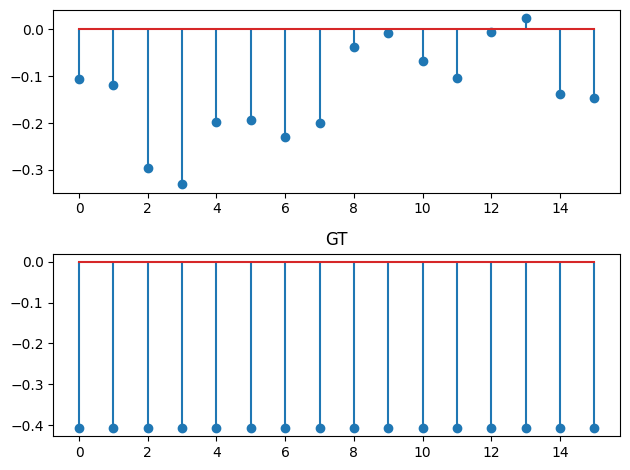

In [96]:
plt.subplot(2,1,1), plt.stem(tf.squeeze(yhat[0,:,0]).numpy())
plt.subplot(2,1,2), plt.stem(tf.squeeze(y1n).numpy()), plt.title('GT')
plt.tight_layout()


In [97]:
tf.reduce_sum(tf.square(yhat)), tf.reduce_sum(tf.square(y1n)), 

(<tf.Tensor: shape=(), dtype=float32, numpy=6.814311981201172>,
 <tf.Tensor: shape=(), dtype=float32, numpy=2.6535372734069824>)